
<h1 id="2.5-%E5%AE%9E%E9%AA%8C%E6%95%B0%E6%8D%AE%E5%A4%84%E7%90%86%E8%BF%87%E7%A8%8B">2.5 实验数据处理过程</h1>



<p>基于 ROOT 的核物理实验数据处理通常可分为两个主要阶段。第一阶段侧重于底层数据的解码、格式转换与初步整理；第二阶段则侧重于物理量的提取与高级物理分析。</p>
<h3 id="%F0%9F%92%A1-%E6%A0%B8%E5%BF%83%E5%8E%9F%E5%88%99%EF%BC%9A%E6%A8%A1%E5%9D%97%E5%8C%96%E8%A7%A3%E8%80%A6%E4%B8%8E%E9%98%B6%E6%AE%B5%E6%80%A7%E6%95%B0%E6%8D%AE%E5%AD%98%E5%82%A8">💡 核心原则：模块化解耦与阶段性数据存储</h3><p>可将分析分为解码、刻度、事件重建和物理分析几个阶段。在计算耗时或需要重复使用的阶段保存中间 ROOT 文件；无需每做一步都另存一个文件。保留原事件编号、输入来源、刻度参数和选择条件，便于复查。</p>
<ul>
<li>避免重复计算：改变末端的 Cut 或拟合区间时，读取已保存的刻度结果，不必重复解码和刻度。</li>
<li><strong>降低代码耦合，提升容错率</strong>：不同层级的分析如果高度耦合，一旦某处逻辑（如某个探测器的刻度参数）发生更改，极易引发连锁错误，且排查困难（Debug 成本极高）。采用分步生成独立文件的方式，使得每个阶段的输入输出清晰明确，不仅便于逐级检查数据质量，也极大提高了代码的可维护性。</li>
</ul>
<h3 id="%E7%AC%AC%E4%B8%80%E9%98%B6%E6%AE%B5%EF%BC%9A%E6%95%B0%E6%8D%AE%E6%A0%BC%E5%BC%8F%E8%BD%AC%E6%8D%A2%E4%B8%8E%E5%88%9D%E6%AD%A5%E6%95%B4%E7%90%86">第一阶段：数据格式转换与初步整理</h3><p>此阶段的目标是将探测器获取的信号读数转换为结构化的 ROOT 数据，并进行基础的清洗和校验。
<img alt="1" src="fig/phase1.png"/></p>
<h4 id="%E5%8E%9F%E5%A7%8B%E6%95%B0%E6%8D%AE(raw-data)"><font color="Blue">原始数据(raw data)</font></h4><ul>
<li>实验过程中由前端数据获取系统（DAQ）产生的二进制数据流保存到硬盘形成原始文件。原始数据通常由一系列的“数据块 (Data Block)”组成。每个数据块内包含来自不同电子学插件的数据，每个数据单元除了包含各个通道记录的探测器幅度值（如 ADC/TDC 读数）外，还包含通道地址、是否超界等状态描述字。</li>
</ul>



<h4 id="%E8%A7%A3%E7%A0%81(decoding-or-mapping)%EF%BC%9A"><font color="Blue">解码(decoding or mapping)</font>：</h4><ul>
<li>解码程序通过读取数据中每个插件的特定标识，按对应协议进行解码。随后，根据实验设定的“探测器信号-插件通道”对应表（Mapping Map），将上述硬件数据转换成每个物理事件中具体探测器的测量值。经过此步骤生成的文件通常称为<strong>原始 ROOT 文件 (Raw ROOT File)</strong>。</li>
</ul>



<h4 id="%E4%BA%8B%E4%BB%B6%E9%87%8D%E6%9E%84(event-building)%EF%BC%9A"><font color="Blue">事件重构(event building)</font>：</h4><ul>
<li>根据探测器信号之间的时间逻辑关系，重新组织和对齐事件结构（具体算法机制见第 5 章）。</li>
</ul>


<h3>步骤一：检查原始道值与量化</h3><p>保留 ADC/TDC 的整数码及无效、overflow 等状态，检查其有效区间。刻度可以直接作用于原始码或 bin 中心。1.3 的 dithering 是基于 bin 内均匀近似的可选处理，不是刻度的必需步骤，也不恢复丢失的精度。</p>


<h4 id="%E6%AD%A5%E9%AA%A4%E4%BA%8C%EF%BC%9A%E5%8F%82%E6%95%B0%E5%AE%8C%E6%95%B4%E6%80%A7%E4%BB%A5%E5%8F%8A%E5%8F%98%E9%87%8F%E6%9C%89%E6%95%88%E5%80%BC%E5%8C%BA%E9%97%B4">步骤二：参数完整性以及变量有效值区间</h4><p>检查每一个实验参数的完整性，并根据数据实际情况选择合适的物理量计算方法：</p>
<ul>
<li><strong>Case 1</strong>：在 PPAC 探测器实验中，若四个位置的时间信号正常，但阳极 (Anode) 信号异常（如接触不良或后端电子学故障），为了最大化利用有效数据，在位置信号的重建算法中，可放宽条件，不强制要求阳极信号的存在。</li>
<li><strong>Case 2</strong>：在中子探测器实验中，如果左侧的电荷量 $q_L$ 记录缺失，可通过时间信号 $t_L, t_R$ 以及右侧电荷量 $q_R$，利用经验公式重建总沉积能量 $Q$。</li>
<li><strong>无效值标记</strong>：只对有效范围内的信号进行刻度处理。对于有效值范围外的数据（如低于台阶/Pedestal的噪声，或溢出/超界数据），应统一设定为与正常物理值有明显区分的特定标记值（例如 <code>-999</code> 或 <code>-1</code>），严禁将其作为有效零值参与物理计算。</li>
</ul>



<h4 id="%E6%AD%A5%E9%AA%A4%E4%B8%89%EF%BC%9A%E5%85%B3%E9%94%AE%E4%BF%A1%E6%81%AF%E7%9A%84%E7%9B%B4%E6%96%B9%E5%9B%BE%E5%8C%96%E5%AD%98%E5%82%A8-(Histograms)">步骤三：关键信息的直方图化存储 (Histograms)</h4><p>反复查看大型 TTree 的同一分布会重复读取数据。可把常用直方图与树一起保存，或另存为 hist001.root，供日常检查；按具体数据量决定是否缓存。</p>
<ul>
<li><strong>常用信息包括</strong>：ADC/TDC 各通道的原始能谱和时间谱、同类型探测器的 Hit 分布图、探测器间的二维关联谱（如 $\Delta E-E$, $TOF-\Delta E$）等。</li>
</ul>
<p><strong>利用目录结构组织直方图：</strong>
当直方图数量庞大时，可使用 <code>TDirectoryFile</code> 在 ROOT 文件内部创建类似文件系统的目录结构，以便于在 <code>TBrowser</code> 中快速浏览。</p>
<p><em>代码示例：在 ROOT 文件中创建目录并分类存储直方图</em></p>
<p><code>root -l mg18.root</code></p>
<pre><code>root[0] new TBrowser
</code></pre>
<pre><code>- 在左侧栏中双击文件名，在Draw Option栏中填入“colz”等绘图选项。</code></pre>
<p><img alt="" src="fig/root-dir.png"/></p>


In [ ]:
gRandom->SetSeed(2501); // 固定示例的随机数种子
// 1. 创建用于存储直方图的 ROOT 文件
TFile *fout = new TFile("hist_test.root", "RECREATE");

// 2. 在根目录下创建一级目录 dir1 和 dir2
TDirectoryFile *dir1 = new TDirectoryFile("dir1", "ADC Spectra");
TDirectoryFile *dir2 = new TDirectoryFile("dir2", "TDC Spectra");

// 3. 在 dir1 下创建子目录 dir1sub
dir1->cd(); 
TDirectoryFile *dir1sub = new TDirectoryFile("dir1sub", "PPAC Detail");

// 4. 声明并初始化直方图 (注意在 new 之前切换到对应的目录)
TH1I *h0, *h1, *h2, *h1sub;

fout->cd();    // 回到根目录
h0 = new TH1I("h0", "Global Hist", 100, -3, 3);

dir1->cd();    // 进入 dir1
h1 = new TH1I("h1", "ADC Channel 1", 100, -3, 3);

dir1sub->cd(); // 进入子目录
h1sub = new TH1I("h1sub", "PPAC X pos", 100, -3, 3);

dir2->cd();    // 进入 dir2
h2 = new TH1I("h2", "TDC Channel 1", 100, -3, 3);

// 5. 填充数据 (实际分析中通常在 Event Loop 中进行)
h0->FillRandom("gaus", 10000);
h1->FillRandom("gaus", 10000);
h1sub->FillRandom("gaus", 10000);
h2->FillRandom("gaus", 10000);

// 6. 一次性将所有内存中的直方图按目录结构写入文件
fout->Write();
fout->Close();

<p>写入后的目录结构：</p><img alt="1" src="fig/dir.png"/>
<h4 id="Read-hist-from-the-file">Read hist from the file</h4><ul>
<li>root环境直接读取(见上图)</li>
</ul>
<div class="highlight"><pre><span></span><span class="n">root</span><span class="w"> </span><span class="o">-</span><span class="n">l</span><span class="w"> </span><span class="n">hist_test</span><span class="p">.</span><span class="n">root</span>
<span class="o">&gt;</span><span class="k">new</span><span class="w"> </span><span class="n">TBrowser</span>
</pre></div>
<p>在左边树形目录结构中找到文件，鼠标点击进入目录结构，点击相应hist</p>
<ul>
<li>代码读取</li>
</ul>


In [ ]:
TFile *fin=new TFile("hist_test.root");

In [11]:
fin->ls();

TFile**		hist_test.root
 TFile*		hist_test.root
  KEY: TDirectoryFile	dir1;1	ADC Spectra
  KEY: TDirectoryFile	dir2;1	TDC Spectra
  KEY: TH1I	h0;1	Global Hist

In [ ]:
TH1I* h0a=(TH1I*) fin->Get("h0");
TH1I* h1a=(TH1I*) fin->Get("dir1/h1");
TH1I* h2a=(TH1I*) fin->Get("dir2/h2");
TH1I* h1suba=(TH1I*) fin->Get("dir1/dir1sub/h1sub");

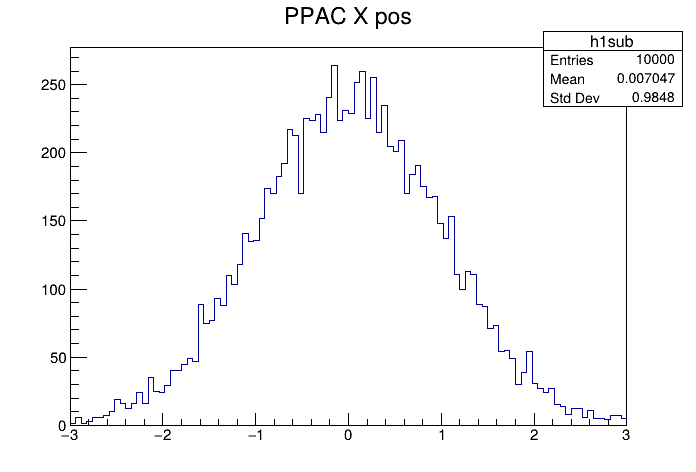

In [13]:
TCanvas *c1 = new TCanvas("c1","Directory example");
h1suba->Draw();
c1->Draw();


<h4 id="%E6%AD%A5%E9%AA%A4%E5%9B%9B%EF%BC%9A%E5%AE%9E%E9%AA%8C%E5%8F%82%E6%95%B0%E4%B8%80%E8%87%B4%E6%80%A7%E6%A3%80%E9%AA%8C-(Drift-Check)">步骤四：实验参数一致性检验 (Drift Check)</h4><p>由于探测器工作条件的变化（温度波动、噪声引入等）以及电子学参数的长期漂移，实验设备的增益或基线可能会随时间发生改变。
<strong>在进入正式物理刻度和设定数据切割条件（Cut）之前，先检查基础参数的时间稳定性，并进行必要的动态修正。</strong></p>
<ul>
<li><strong>文件内变化</strong>：观察参数值随事件编号（Event Number）或绝对时间戳（Timestamp）的变化趋势。</li>
<li><strong>全局变化</strong>：观察参数的统计平均值（如某特征峰的位置、探测器效率、时间分辨）随 Run Number（文件编号）的宏观漂移情况。</li>
</ul>
<p>下图显示某次实验中TDC值、位置探测器分辨、效率等参数随着文件号的变化。
<img alt="3" src="fig/values_run.png"/></p>



<h2 id="%E7%AC%AC%E4%BA%8C%E9%98%B6%E6%AE%B5%EF%BC%9A%E7%89%A9%E7%90%86%E9%87%8F%E6%8F%90%E5%8F%96%E4%B8%8E%E9%AB%98%E7%BA%A7%E5%88%86%E6%9E%90">第二阶段：物理量提取与高级分析</h2><p>第二阶段建立在第一阶段清洗和校准好的数据之上，主要包括物理量（如散射角、激发能、反应截面）的严格提取、物理条件的选取（Cut 应用）以及最终物理图谱的拟合等过程。</p>
<p>本阶段用刻度后的信号重建物理量。选择条件会改变样本及其接受度，应与重建结果一起记录，供后续效率修正使用。</p>
<h3 id="1.-%E7%89%A9%E7%90%86%E6%9D%A1%E4%BB%B6%E7%9A%84%E9%80%89%E5%8F%96%EF%BC%88Cut-%E5%BA%94%E7%94%A8%EF%BC%89">1. 物理条件的选取（Cut 应用）</h3><p>在提取最终物理观测量之前，必须从混杂的实验数据中精准筛选出目标反应事件，并最大程度压低本底。该过程通常通过在 ROOT 中施加多维度的条件切割（Cuts）来实现：</p>
<ul>
<li><strong>粒子鉴别（Particle Identification, PID）</strong>：利用探测器组（如 $\Delta E-E$ 望远镜探测器或 $TOF-\Delta E$ 飞行时间系统），绘制二维关联散点图。不同电荷 $Z$ 和质量 $M$ 的同位素会在二维图上呈现清晰的“带状”分布。通过在 ROOT 中运用 <code>TCutG</code> 类，沿着目标粒子的分布带绘制闭合多边形，生成 PID 筛选条件。</li>
<li>符合时间窗口选取（Time Window Cut）：围绕探测器时间差的 prompt 峰选择事件，以降低 random coincidence。本底仍可能落在窗口内，必要时用旁侧时间区间估计。</li>
<li><strong>几何与运动学约束</strong>：排除打在探测器边缘死区或准直器上的无效事例，或利用反应前后的动量守恒逻辑，剔除不符合特定运动学规律的发散事件。</li>
</ul>
<h3 id="2.-%E7%89%A9%E7%90%86%E9%87%8F%E7%9A%84%E4%B8%A5%E6%A0%BC%E6%8F%90%E5%8F%96%EF%BC%88Kinematic-Reconstruction%EF%BC%89">2. 物理量的严格提取（Kinematic Reconstruction）</h3><p>经过 Cut 选择后的候选事件，其中使用的量包括探测器坐标（$X, Y, Z$）和校准后的能量（MeV）、时间（ns）。在此步骤中，需要利用相对论或经典运动学公式，将这些基础观测量转化为表征原子核性质的物理参量：</p>
<ul>
<li><strong>散射角提取（Scattering Angle）</strong>：结合靶点位置与粒子在位置敏感探测器（如 PPAC、硅微条）上的击中坐标，利用空间几何关系计算出粒子出射的极角 $\theta$ 和方位角 $\phi$。</li>
<li><strong>激发能与 Q 值重构（Excitation Energy）</strong>：利用入射束流能量、出射粒子的动能与散射角 $\theta$，通过两体或多体运动学公式（Kinematics），逐事件（Event-by-Event）计算出反应体系的 $Q$ 值或剩余核的激发能 $E_x$。</li>
</ul>
<h3 id="3.-%E6%9C%80%E7%BB%88%E7%89%A9%E7%90%86%E5%9B%BE%E8%B0%B1%E7%9A%84%E6%8B%9F%E5%90%88%E4%B8%8E%E6%88%AA%E9%9D%A2%E8%AE%A1%E7%AE%97%EF%BC%88Spectrum-Fitting%EF%BC%89">3. 最终物理图谱的拟合与截面计算（Spectrum Fitting）</h3><p>将提取出的物理量（如 $E_x$）投影为一维直方图后，即得到最终的物理图谱。后续的物理分析主要围绕图谱的解析展开：</p>
<ul>
<li><strong>信号拟合与本底扣除</strong>：利用 ROOT 中的 <code>TF1</code> 类定义拟合函数。针对目标物理峰（如基态、激发态谱线），通常采用高斯函数（Gaussian）或布雷特-维格纳函数（Breit-Wigner）进行拟合；针对连续分布的物理本底，通常采用多项式或指数函数进行背景建模。通过拟合，可在给定模型下估计特定物理态的中心位置（对应能级）、峰宽（需分离自然宽度与仪器分辨后才可能关联寿命）以及净计数（Yield）。</li>
<li><strong>反应截面提取（Cross Section）</strong>：物理图谱中提取的净计数 $N$ 仅代表探测到的事例数。要获得具有普适物理意义的反应截面 $\sigma$，需结合实验中的束流积分流强、靶原子面密度，并引入探测器本征效率与几何接受度（通常由 Geant4 等蒙特卡罗软件模拟给出）进行严格的归一化修正。</li>
</ul>
<p><img alt="2" src="fig/phase2.png"/></p>
<p>重建后可只保留后续分析需要的量以减少重复读取，同时保留能追溯到原事件的编号。</p>



<hr/>
<h1 id="Bash-shell-script-tutorial">Bash shell script tutorial</h1><p>在核物理实验数据分析中，<strong>Bash 脚本则负责上层工作流的“自动化统筹”</strong>。</p>
<p>当我们将核心物理算法（如 2.4 节中的 <code>./tracking</code>）编译为独立的可执行文件后，面对实验中产生的几十甚至上百个数据文件（Run），手动逐一输入命令显然是不切实际的。在真实的分析场景中，我们通常面临以下核心需求：</p>
<ol>
<li><strong>批量处理 (Batch Processing)</strong>：能够一键循环处理连续的 Run。</li>
<li><strong>动态传参 (Parameterization)</strong>：允许通过命令行灵活指定要处理的 Run 范围。</li>
<li><strong>容错机制 (Error Handling)</strong>：自动检测文件是否损坏或缺失，避免程序崩溃。</li>
<li><strong>后台挂机与日志 (Background &amp; Logging)</strong>：对于耗时数小时的分析任务，需支持断开终端连接后继续运行，并记录终端输出。</li>
</ol>
<p>以下教程将分为 4 个层级，逐步建立数据分析自动化脚本。</p>
<h3 id="Level-1%EF%BC%9A%E6%9C%80%E5%9F%BA%E7%A1%80%E7%9A%84%E7%BB%88%E7%AB%AF%E5%BE%AA%E7%8E%AF-(One-Liner)">Level 1：最基础的终端循环 (One-Liner)</h3><p>如果你只需临时快速跑完 Run 1 到 Run 10，甚至不需要专门编写脚本文件，直接在 Linux 终端中输入一行命令即可完成批量提交：</p>
<div class="highlight"><pre><code class="language-cpp">for run in {1..10}; do ./tracking $run; done</code></pre></div>
<ul>
<li><strong>语法解析</strong>：<ul>
<li><code>for run in {1..10}</code>：定义变量 <code>run</code>，使其取值从 1 递增到 10。</li>
<li><code>do ... done</code>：Bash 的循环体结构，内部包含每次循环要执行的具体命令。</li>
<li><code>$run</code>：在 Bash 中，调用变量的值必须在变量名前加 <code>$</code> 符号。</li>
</ul>
</li>
</ul>
<hr/>
<h3 id="Level-2%EF%BC%9A%E5%B8%A6%E5%8F%82%E6%95%B0%E7%9A%84%E5%9F%BA%E7%A1%80%E8%84%9A%E6%9C%AC-(%E5%8F%98%E9%87%8F%E4%B8%8E%E4%BC%A0%E5%8F%82)">Level 2：带参数的基础脚本 (变量与传参)</h3><p>为了将执行逻辑固化并方便复用，通常创建一个 Shell 脚本文件（如 <code>run_batch.sh</code>）。为了避免每次修改代码内部的数字，我们需要引入<strong>命令行传参</strong>功能。</p>
<p>新建文件 <code>run_batch.sh</code>，写入以下内容：</p>
<div class="highlight"><pre><code class="language-cpp">#!/bin/bash
# 第一行称为 Shebang，告知系统使用 bash 解释器来运行此脚本

# $1 表示用户输入的第一个参数（起始Run），$2 表示第二个参数（结束Run）
START=$1
END=$2

echo "&gt;&gt;&gt; 准备分析从 Run $START 到 Run $END 的数据..."

# 使用 seq 命令生成从 START 到 END 的连续数字序列
for run in $(seq "$START" "$END"); do
    echo "--- 正在处理 Run $run ---"
    ./tracking $run
done

echo "&gt;&gt;&gt; 所有任务执行完毕！"</code></pre></div>
<ul>
<li><strong>使用方法</strong>：<ol>
<li>赋予脚本可执行权限：<code>chmod +x run_batch.sh</code></li>
<li>运行脚本并传入起止 Run 号：<code>./run_batch.sh 10 20</code></li>
</ol>
</li>
</ul>
<hr/>
<h3 id="Level-3%EF%BC%9A%E5%A4%8D%E6%9D%82%E6%95%B0%E6%8D%AE%E5%88%86%E6%9E%90%E8%84%9A%E6%9C%AC-(%E6%A0%BC%E5%BC%8F%E5%8C%96%E4%B8%8E%E5%AE%B9%E9%94%99%E5%A4%84%E7%90%86)">Level 3：复杂数据分析脚本 (格式化与容错处理)</h3><p>在真实实验中，数据文件通常带有补零格式（如 <code>run001.root</code> 而非 <code>run1.root</code>），且常常会因为各种原因跳过某些 Run。此时，我们需要在脚本中加入<strong>字符串格式化</strong>与<strong>文件存在性检测</strong>。</p>
<p>更新 <code>run_batch.sh</code>，加入容错逻辑与目录管理：</p>
<div class="highlight"><pre><code class="language-cpp">#!/bin/bash

# 1. 参数数量安全校验
if [ "$#" -ne 2 ]; then
    echo "用法错误! 正确格式: ./run_batch.sh &lt;开始Run号&gt; &lt;结束Run号&gt;"
    exit 1
fi

START=$1
END=$2
IN_DIR="./data"       # 假设原始数据存放在 data 目录下
OUT_DIR="./output"    # 定义输出归档目录

# 2. 创建输出目录（-p 表示如果目录已存在则不报错）
mkdir -p "$OUT_DIR"

for run in $(seq "$START" "$END"); do
    # 3. 核心技巧：使用 printf 将数字 1 格式化为 001
    RUN_FMT=$(printf "%03d" $run)
    FILE_NAME="f8ppac${RUN_FMT}.root"

    # 4. 容错检测：-f 判断原始文件是否存在
    if [ ! -f "${IN_DIR}/${FILE_NAME}" ]; then
        echo "警告: 找不到文件 ${IN_DIR}/${FILE_NAME}，自动跳过..."
        continue # 跳过本次循环，直接进入下一个 Run
    fi

    # 5. 执行核心 C++ 分析程序
    echo "&gt;&gt;&gt; 开始处理 Run ${RUN_FMT} ..."
    if ! ./tracking "$run" "$IN_DIR" "$OUT_DIR"; then
        echo "Run $run failed" &gt;&amp;2
        continue
    fi

done</code></pre></div>
<hr/>
<h3 id="Level-4%EF%BC%9A%E6%9C%8D%E5%8A%A1%E5%99%A8%E4%B8%8A%E7%9A%84%E5%90%8E%E5%8F%B0%E6%8C%82%E6%9C%BA%E4%B8%8E%E6%97%A5%E5%BF%97%E7%9B%91%E6%8E%A7-(nohup)">Level 4：服务器上的后台挂机与日志监控 (nohup)</h3><p>处理海量实验数据通常需要运行数小时。如果直接在终端运行 <code>./run_batch.sh 1 100</code>，关闭终端或 SSH 连接可能发送 SIGHUP；电脑休眠会暂停本机任务。nohup 不能防止休眠、重启或资源限制导致的终止。</p>
<p><strong>后台运行可使用 <code>nohup</code> (No Hang Up) 与后台符 <code>&amp;</code>。</strong></p>
<p>在终端输入以下完整命令：</p>
<div class="highlight"><pre><code class="language-cpp">nohup ./run_batch.sh 1 100 &gt; analysis.log 2&gt;&amp;1 &amp;</code></pre></div>
<ul>
<li><strong>语法解析</strong>：<ul>
<li><code>nohup</code>：忽略系统的挂断信号，即使关闭终端窗口，程序也会继续在服务器上运行。</li>
<li><code>&gt; analysis.log</code>：将原本要在屏幕上打印的所有标准输出（如 C++ 中的 <code>std::cout</code>），重定向保存到 <code>analysis.log</code> 文本文件中。</li>
<li><code>2&gt;&amp;1</code>：将标准错误（2，如 <code>std::cerr</code> 的报错信息）一并合并到标准输出（1）中，确保报错日志不丢失。</li>
<li><code>&amp;</code>：放在命令最末尾，表示将该任务放入<strong>后台（Background）</strong>执行。按下回车后，终端立刻恢复自由状态，你可以继续输入其他命令。</li>
</ul>
</li>
</ul>
<p><strong>如何实时监控后台进度？</strong>
虽然程序在后台静默运行，但你可以随时查看日志文件的最新动态以监控进度：</p>
<div class="highlight"><pre><code class="language-cpp"># -f (follow) 选项会实时追踪并刷新日志文件的末尾输出
tail -f analysis.log</code></pre></div>
<p><em>(查看完毕后，按 <code>Ctrl + C</code> 即可退出日志监控，这不会影响后台程序的运行。)</em></p>
